## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data-Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
3. ...

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates
from collections import Counter
import re

In [22]:
df = pd.read_csv("klacht_train.csv")

### Data Analyse

In [23]:
df.head().T

,0,1,2,3,4
ID,1753142,1304291,1532095,1479068,2367063
Datum_ontvangst,2024-01-21,2023-03-27,2023-08-23,2023-07-21,2025-03-01
Product,Hypotheek,Hypotheek,Bankrekening,Incasso,Incasso
Omschrijving,My financial hardship began when my husband wh...,On or about XXXX XXXX I applied for a modifica...,I have XXXX bad things on Regions bank that ju...,This was a payday loan from XXXX and the callI...,I got an alert today that the company SENTRY C...
Antwoord_bedrijf,Closed with explanation,Closed with explanation,Closed with explanation,Untimely response,Closed with explanation
Omschrijving_lengte,1837,2627,397,144,512
Antwoord_lengte,23,23,23,17,23


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11909 entries, 0 to 11908
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   11909 non-null  int64 
 1   Datum_ontvangst      11909 non-null  object
 2   Product              11909 non-null  object
 3   Omschrijving         11909 non-null  object
 4   Antwoord_bedrijf     11909 non-null  object
 5   Omschrijving_lengte  11909 non-null  int64 
 6   Antwoord_lengte      11909 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 651.4+ KB


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,11909.0,1.904232e+06,340644.796083,1290157.0,1602650.0,1926095.0,2206534.0,2543247.0
Omschrijving_lengte,11909.0,1.025507e+03,916.164458,12.0,379.0,713.0,1371.0,10761.0
Antwoord_lengte,11909.0,2.379923e+01,3.916677,6.0,23.0,23.0,23.0,31.0


In [26]:
df['Product'].unique()

array(['Hypotheek', 'Bankrekening', 'Incasso', 'Kredietregistratie',
       'Creditcard', 'Consumentenkrediet'], dtype=object)

In [27]:
df['Antwoord_bedrijf'].unique()

array(['Closed with explanation', 'Untimely response',
       'Closed with non-monetary relief', 'Closed with monetary relief',
       'Closed'], dtype=object)

In [28]:
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

In [29]:
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 11909 rijen en 7 kolommen.


In [30]:
# Numeriek
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0,1,2
index,ID,Omschrijving_lengte,Antwoord_lengte
count,11909.0,11909.0,11909.0
mean,1904231.57402,1025.506592,23.799227
std,340644.796083,916.164458,3.916677
min,1290157.0,12.0,6.0
25%,1602650.0,379.0,23.0
50%,1926095.0,713.0,23.0
75%,2206534.0,1371.0,23.0
max,2543247.0,10761.0,31.0


In [31]:
# Categorisch
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,11909,770,2024-10-17,38
1,Product,11909,6,Incasso,3237
2,Omschrijving,11909,11859,I am filing this complaint because Experian ha...,8
3,Antwoord_bedrijf,11909,5,Closed with explanation,9281


In [32]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               3237
Hypotheek             2675
Kredietregistratie    2576
Creditcard            1477
Bankrekening          1186
Consumentenkrediet     758
Name: count, dtype: int64

#### Visualisaties

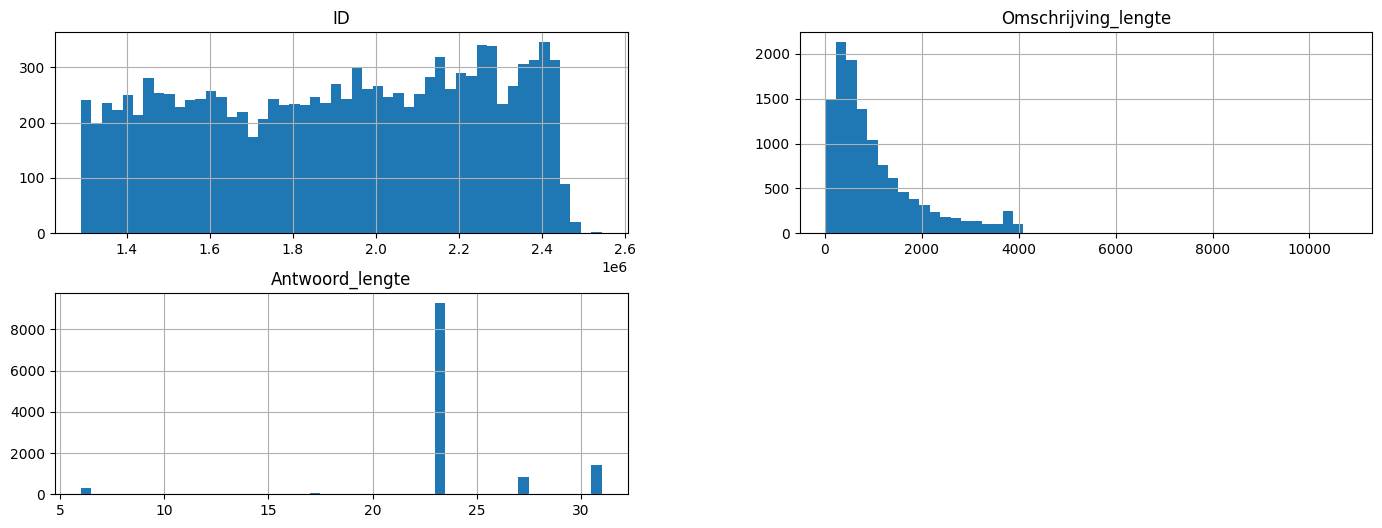

In [33]:
df.hist(bins=50, figsize=(17, 6))
plt.show()

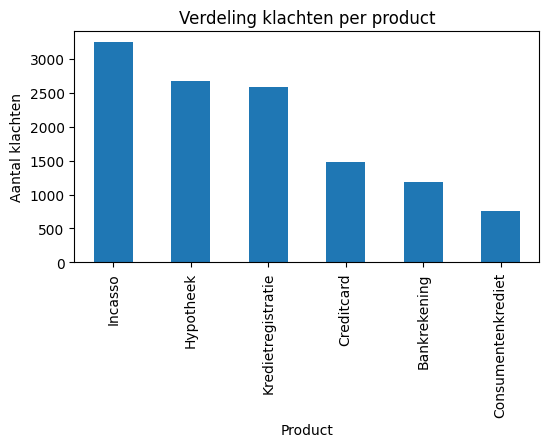

In [34]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
df['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

In [35]:
# datum string omzetten naar datetime
df['Datum_ontvangst'] = pd.to_datetime(df['Datum_ontvangst'])
counts = df.groupby(df['Datum_ontvangst'].dt.to_period('M')).size()
counts.index = counts.index.to_timestamp() 

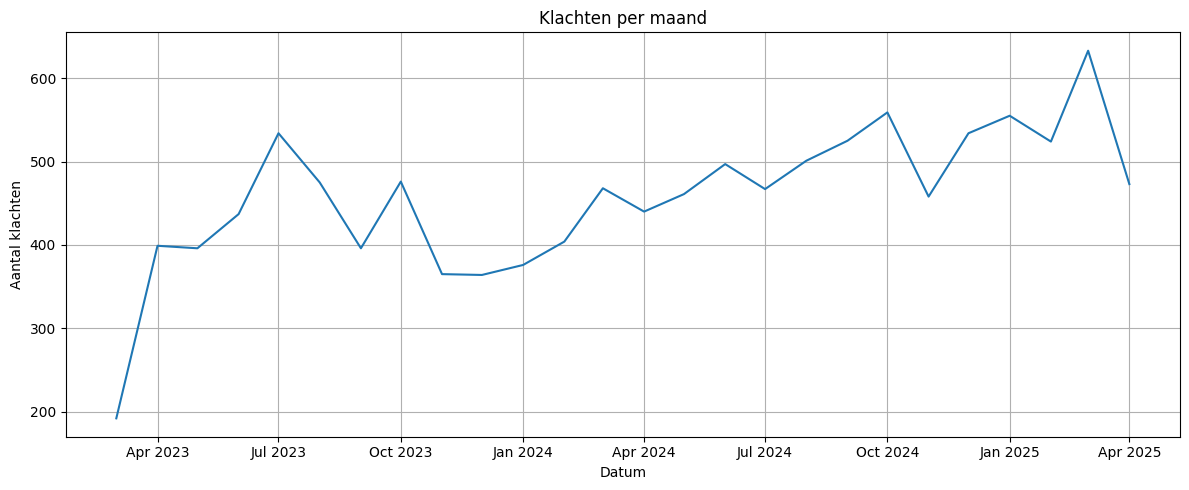

In [36]:
counts = df.groupby(df['Datum_ontvangst'].dt.to_period('M')).size() # groeperen op jaar-maand en aantallen per maand tellen 
counts.index = counts.index.to_timestamp() 

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(counts.index, counts.values)

# maand - jaar labels 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Klachten per maand")
plt.xlabel("Datum")
plt.ylabel("Aantal klachten")
plt.grid(True)
plt.tight_layout()
plt.show()

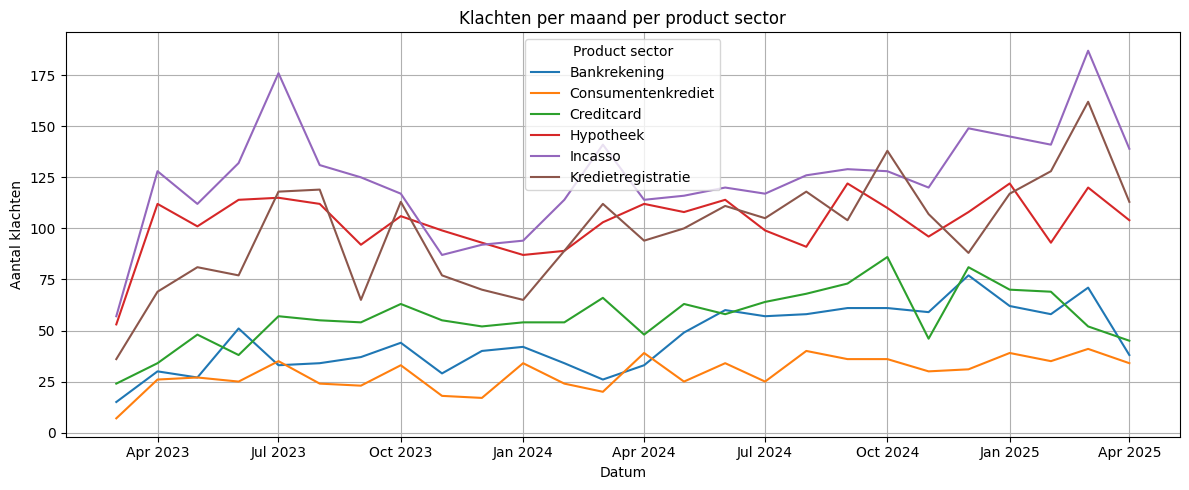

In [ ]:
counts_sector = (
    df.groupby([df['Datum_ontvangst'].dt.to_period('M'), 'Product']).size().unstack(fill_value=0))


counts_sector.index = counts_sector.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,5))

for sector in counts_sector.columns:
    ax.plot(counts_sector.index, counts_sector[sector], label=sector)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title("Klachten per maand per product sector")
plt.xlabel("Datum")
plt.ylabel("Aantal klachten")
plt.legend(title="Product sector")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
word_counts = df['Omschrijving'].str.split(expand=True).stack().value_counts()
print(word_counts)

the              84927
I                79385
XXXX             75197
to               73873
and              58719
                 ...  
misdirection         1
Financ               1
TRUE.                1
village              1
immediately.I        1
Name: count, Length: 49139, dtype: int64


In [55]:
filtered_df = df[df['Product'] == 'Bankrekening']

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

filtered_words = filtered_df['Omschrijving'].apply(tokenize).explode()

word_counts_Bankrekening = Counter(filtered_words)

In [54]:
filtered_df = df[df['Product'] == 'Consumentenkrediet']

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

filtered_words = filtered_df['Omschrijving'].apply(tokenize).explode()

word_counts_Consumentenkrediet = Counter(filtered_words)

In [56]:
filtered_df = df[df['Product'] == 'Creditcard']

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

filtered_words = filtered_df['Omschrijving'].apply(tokenize).explode()

word_counts_Creditcard = Counter(filtered_words)

In [57]:
filtered_df = df[df['Product'] == 'Hypotheek']

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

filtered_words = filtered_df['Omschrijving'].apply(tokenize).explode()

word_counts_Hypotheek = Counter(filtered_words)

In [58]:
filtered_df = df[df['Product'] == 'Incasso']

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

filtered_words = filtered_df['Omschrijving'].apply(tokenize).explode()

word_counts_Incasso = Counter(filtered_words)

In [59]:
filtered_df = df[df['Product'] == 'Kredietregistratie']

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

filtered_words = filtered_df['Omschrijving'].apply(tokenize).explode()

word_counts_Kredietregistratie = Counter(filtered_words)

In [60]:
print("Word Frequency for 'Bankrekening':")
print(word_counts_Bankrekening)

print("Word Frequency for 'Consumentenkrediet':")
print(word_counts_Consumentenkrediet)

print("Word Frequency for 'Creditcard':")
print(word_counts_Creditcard)

print("Word Frequency for 'Hypotheek':")
print(word_counts_Hypotheek)

print("Word Frequency for 'Incasso':")
print(word_counts_Incasso)

print("Word Frequency for 'Kredietregistratie':")
print(word_counts_Kredietregistratie)

Word Frequency for 'Bankrekening':
Counter({'the': 12179, 'xxxx': 10808, 'i': 10382, 'to': 9219, 'and': 7094, 'my': 5520, 'a': 5332, 'that': 4399, 'of': 4288, 'was': 3976, 'account': 3653, 'in': 3135, 'bank': 2994, 'they': 2868, 'on': 2803, 'me': 2632, 'for': 2600, 'not': 2586, 'have': 2532, 'this': 2299, 'with': 2170, 'is': 2166, 'it': 2104, '00': 1708, 'from': 1471, 'xx': 1465, 'had': 1399, 'be': 1287, 'as': 1276, 'money': 1094, 'an': 1078, 'would': 1076, 'at': 1039, 'told': 997, 'by': 912, 'been': 911, 'but': 896, 'no': 865, 'card': 865, 'check': 826, 't': 824, 'did': 814, 'them': 805, 'do': 778, 'we': 773, 'n': 751, 'or': 751, 'were': 746, 'when': 734, 'are': 732, 'credit': 728, 'their': 722, 'has': 683, 'so': 679, 'all': 673, 'fees': 673, 'which': 670, 'after': 669, 'funds': 657, 's': 631, 'out': 629, 'called': 628, 'time': 623, 'if': 622, 'checking': 614, 'chase': 608, 'any': 605, 'am': 593, 'because': 592, 'back': 575, 'will': 572, 'there': 554, 'received': 551, 'she': 551, 'you

### Analyse per product

### Analyse per specifieke feature